# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
# Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Set pandas display option
pd.set_option('display.max_columns', None)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
# Type your code here

# Opsi 1: Jika dataset kamu upload manual ke folder session Colab (paling mudah)
file_path = 'credit_risk_dataset.csv'

# Opsi 2: Jika menggunakan Google Drive (Uncomment baris di bawah jika pakai Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = '/content/drive/MyDrive/lokasi_folder/credit_risk_dataset.csv'

# Membaca dataset
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk memastikan data termuat
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


===

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


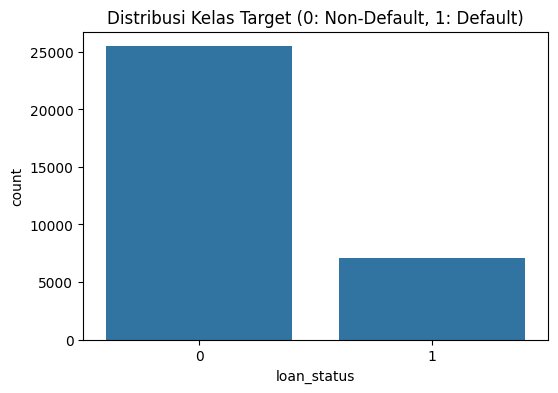

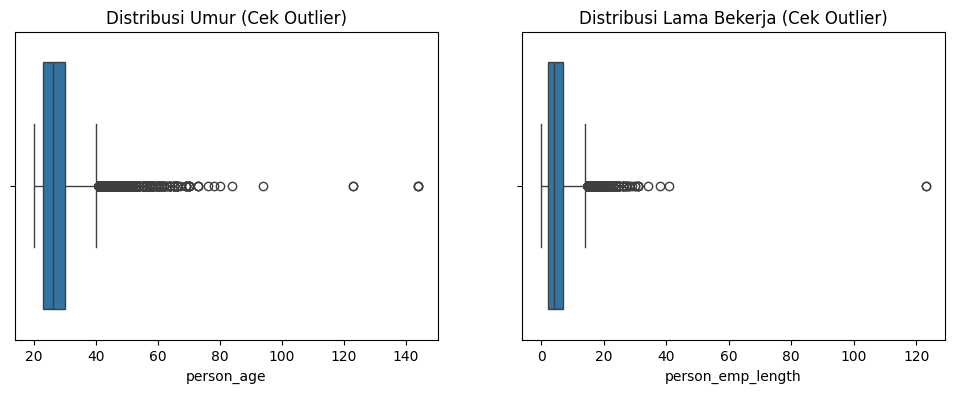

In [5]:
# Type your code here
print("=== Informasi Dataset ===")
df.info()
print("\n")

print("=== Pengecekan Missing Values ===")
print(df.isnull().sum())
print("\n")

print("=== Pengecekan Data Duplikat ===")
print("Jumlah duplikat:", df.duplicated().sum())
print("\n")

print("=== Statistik Deskriptif ===")
display(df.describe())

# Visualisasi Target (loan_status)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status')
plt.title('Distribusi Kelas Target (0: Non-Default, 1: Default)')
plt.show()

# Visualisasi Outlier pada Umur dan Lama Bekerja
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='person_age', ax=ax[0])
ax[0].set_title('Distribusi Umur (Cek Outlier)')
sns.boxplot(data=df, x='person_emp_length', ax=ax[1])
ax[1].set_title('Distribusi Lama Bekerja (Cek Outlier)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
# Type your code here

# 1. Menghapus Data Duplikat
df = df.drop_duplicates()
print("Jumlah data setelah hapus duplikat:", len(df))

# 2. Penanganan Outlier (Menghapus anomali ekstrem)
# Dari data, terdapat umur 144 tahun dan lama kerja 123 tahun (sangat tidak wajar)
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 100]

# 3. Menangani Missing Values
# person_emp_length dan loan_int_rate memiliki nilai kosong (NaN)
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Cek kembali Missing Value
print("\nSisa Missing Value setelah ditangani:")
print(df.isnull().sum().sum())

# 4. Memisahkan Fitur (X) dan Target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 5. Encoding Data Kategorikal (One-Hot Encoding atau Label Encoding)
# Kolom kategori: person_home_ownership, loan_intent, loan_grade, cb_person_default_on_file
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 6. Membagi Dataset (Train dan Test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Normalisasi / Standarisasi (Feature Scaling)
scaler = StandardScaler()
# Cukup fitur numerik saja, namun di sini kita scale semua untuk penyederhanaan
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke Dataframe (opsional, agar lebih rapi)
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\nTahap Preprocessing Selesai!")
print("Dimensi X_train:", X_train_final.shape)
print("Dimensi X_test:", X_test_final.shape)
display(X_train_final.head())

Jumlah data setelah hapus duplikat: 32416

Sisa Missing Value setelah ditangani:
0

Tahap Preprocessing Selesai!
Dimensi X_train: (25217, 22)
Dimensi X_test: (6305, 22)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,-0.111100,-0.614193,0.054818,-1.048805,-0.369180,-0.745534,0.053058,-0.057466,-0.285132,-1.018128,-0.498488,-0.353277,-0.478496,2.207090,-0.460378,1.458461,-0.501524,-0.356535,-0.177592,-0.087131,-0.044124,-0.465872
1,0.212991,0.806331,-1.183621,1.641919,-0.147854,0.195800,0.300782,-0.057466,-0.285132,-1.018128,-0.498488,2.830638,-0.478496,-0.453085,-0.460378,-0.685654,1.993923,-0.356535,-0.177592,-0.087131,-0.044124,2.146513
2,-0.921327,-0.125160,0.302506,-0.099138,-1.270759,-0.180734,-0.442390,-0.057466,-0.285132,0.982194,2.006068,-0.353277,-0.478496,-0.453085,-0.460378,-0.685654,-0.501524,-0.356535,-0.177592,-0.087131,-0.044124,-0.465872
3,-0.921327,-0.319143,0.054818,-0.684766,1.098734,-0.557268,-0.937838,-0.057466,-0.285132,0.982194,2.006068,-0.353277,-0.478496,-0.453085,-0.460378,-0.685654,-0.501524,2.804770,-0.177592,-0.087131,-0.044124,-0.465872
4,1.671401,-0.105754,-1.183621,-1.365361,-0.518901,-1.404468,2.778021,-0.057466,-0.285132,0.982194,-0.498488,-0.353277,-0.478496,2.207090,-0.460378,1.458461,-0.501524,-0.356535,-0.177592,-0.087131,-0.044124,-0.465872


In [7]:
# Menggabungkan X_train_final dan y_train untuk disimpan
train_data = pd.concat([X_train_final, y_train.reset_index(drop=True)], axis=1)
train_data.to_csv('credit_risk_preprocessed.csv', index=False)
print("Data preprocessed berhasil disimpan!")

Data preprocessed berhasil disimpan!
